[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch03_workbook.ipynb)

# Three words after "the cat sat on the"

A count model gives a word the number of times it followed the same words in
its training text, divided by the number of times those words occurred, so a
word it never saw after them gets nothing. Four sentences follow "the cat sat
on the" with "mat" once and never with "bed" or "floor": would a table of
their counts rank mat, bed and floor as English does?

In [1]:
#@title Setup: run this cell first
import math
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# Every chart is 6 by 3.5 inches, laid out so that no label is cut off.
plt.rcParams.update({"figure.figsize": (6, 3.5), "figure.autolayout": True})
# The lecture's running example: decks/ch03/question.tex, from decks/ch03/deck.tex, lines 386-389.
SENTENCES = ("the cat sat on the mat", "the dog sat on the rug", "the cat chased the dog", "the dog chased the cat")
D = 0.75  # the four sentences' discount, on the frame "Kneser-Ney Takes ... From Every Seen Count and Shares It ..."
ORDERS = range(1, 5 + 1)  # the novel's models, order 1 to order 5
# GPT-2's next-word probabilities after "The cat sat on the", as the frame "Three Words After 'the cat
# sat on the', Counted and Predicted" prints them: tools/atlas_gpt2.py, model gpt2, revision 607a30d,
# figures/data/atlas-gpt2.json. The deck measured them; no cell here computes them.
GPT2 = {"floor": 0.0764, "bed": 0.0653, "mat": 0.0040}
STYLES = ({"color": "0.6"}, {"color": "C0", "hatch": "//", "edgecolor": "w"})


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def need(ok, name, value, rule):  # repr fails past 4,300 digits, so a long whole number is described
    if not ok:
        what = "a number of more than 40 digits" if isinstance(value, int) and abs(value) > 10 ** 40 else repr(value)[:40]
        raise Refused(f"{name} is {what}, of type {type(value).__name__}: {rule}.")
    return value


# 0, or a number from lo to hi: below lo, an unseen pair's k / (C(u) + k·V) would leave printed digits.
def number(value, name, hi, lo=1e-6):
    ok = isinstance(value, (int, float)) and not isinstance(value, bool) and (value == 0 or lo <= value <= hi)
    return float(need(ok, name, value, f"it must be 0 or a number from {lo:g} to {hi}"))


# Each sentence's pairs: <s> is given before its first word, and </s> is predicted after its last.
pairs = Counter(p for s in SENTENCES for p in zip(["<s>"] + s.split(), s.split() + ["</s>"]))
C = Counter(u for u, w in pairs.elements())  # each first word's count
cont = Counter(w for u, w in pairs)  # the distinct words before each word: its continuation count
fol = Counter(u for u, w in pairs)  # the distinct words after each first word
NEXT = list(cont)  # the nine words a model predicts, </s> among them, in order of first use
V = len(NEXT)


def addk(u, w, k=0):  # k = 0 gives the count over the count
    return (pairs[u, w] + k) / (C[u] + k * V)


def kn(u, w):  # λ(u) = D · fol[u] / C[u], shared by continuation count
    return max(pairs[u, w] - D, 0) / C[u] + D * fol[u] / C[u] * cont[w] / len(pairs)


RULES = {"add-one": lambda u, w: addk(u, w, 1), "Kneser-Ney": kn}


def fmt(p, d=3):  # d decimals from 0.01 up; two significant digits below 0.01; 0 as the frames print it
    return f"{p:.{d}f}" if p >= 0.01 else f"{p:.2g}" if p else "0"


# A typed sentence's pairs, its words split as the novel's are: 1 to 8 of the eight words.
def sentence(text, name):
    w = re.findall(r"[a-z]+(?:'[a-z]+)*", text.lower().replace("’", "'")) if isinstance(text, str) else []
    need(0 < len(w) <= 8 and set(w) <= set(NEXT) - {"</s>"}, name, text, "it must hold 1 to 8 words, each one of "
         f"{', '.join(sorted(set(NEXT) - {'</s>'}))}: no other word has a count")
    return list(zip(["<s>"] + w, w + ["</s>"]))


def perplexity(rows, p):  # two to the mean cost in bits; None when a prediction has probability 0
    return 2 ** (-sum(math.log2(p(u, w)) for u, w in rows) / len(rows)) if all(p(u, w) for u, w in rows) else None


# One or two bars per label, the second series hatched. A value of None has no bound: its bar is
# hatched, edged in red and stopped one unit past the largest bounded value.
def show_bars(labels, xlabel, series):
    fig, ax = plt.subplots()
    end = 1 + max([p for ps in series.values() for p in ps if p is not None], default=0)
    for j, ((name, ps), style) in enumerate(zip(series.items(), STYLES)):
        y = [i + (2 * j + 1 - len(series)) * 0.4 / len(series) for i in range(len(labels))]
        bars = ax.barh(y, [end if p is None else p for p in ps], 0.8 / len(series), label=name, **style)
        ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False, fontsize=8)  # before any capping
        plt.setp([r for r, p in zip(bars, ps) if p is None], hatch="//", facecolor="0.85", edgecolor="C3")
        ax.bar_label(bars, ["no bound, capped" if p is None else fmt(p) for p in ps], fontsize=8, padding=2)
    ax.set(yticks=range(len(labels)), yticklabels=labels, ylim=(len(labels) - 0.5, -0.5), xlabel=xlabel, xmargin=0.35)
    plt.show()


# The novel: the first nine tenths of its chapters train and the last tenth tests; a test word the
# training chapters lack becomes <unk>.
chapters = load_novel()
n_train = round(0.9 * len(chapters))
train = [w for c in chapters[:n_train] for w in c]
grams = {n: Counter(zip(*(train[i:] for i in range(n)))) for n in ORDERS}
test = [w if (w,) in grams[1] else "<unk>" for c in chapters[n_train:] for w in c]
r = {n: Counter(c.values()) for n, c in grams.items()}  # r[n][x]: the number of n-grams of order n seen x times
DN = {n: r[n][1] / (r[n][1] + 2 * r[n][2]) for n in grams}  # each order's own discount (Ney, Essen and Kneser 1994)


def level(c):  # an order's counts, each history's total, and its number of distinct next words
    return c, Counter(g[:-1] for g in c.elements()), Counter(g[:-1] for g in c)


seen = {n: level(grams[n]) for n in grams}  # occurrences
cont_n = {n: level(Counter(g[1:] for g in grams[n + 1])) for n in ORDERS[:-1]}  # continuation counts


# Interpolated Kneser-Ney of order m over 1/V: occurrences at order m, continuation counts below it,
# DN[n] at order n; a history the training chapters lack leaves the order below it to predict.
def p_novel(h, w, m):
    p = 1 / (len(grams[1]) + 1)  # the training chapters' word types and <unk>
    for n in range(1, m + 1):
        c, tot, after = seen[n] if n == m else cont_n[n]
        g = h[len(h) - n + 1:]
        p = max(c[g + (w,)] - DN[n], 0) / tot[g] + DN[n] * after[g] / tot[g] * p if tot[g] else p
    return p


AT = range(ORDERS[-1] - 1, len(test))  # every order predicts the same test positions
pp = [2 ** (-sum(math.log2(p_novel(tuple(test[i - ORDERS[-1] + 1:i]), test[i], m)) for i in AT) / len(AT)) for m in ORDERS]
unseen = [100 * sum(seen[m][0][tuple(test[i - m + 1:i + 1])] == 0 for i in AT) / len(AT) for m in ORDERS]
print(f"Four padded sentences: {sum(pairs.values())} predictions of {V} words, {len(pairs)} pair types. Pride and Prejudice: "
      f"{n_train} chapters train ({len(train):,} tokens, {len(grams[1]) + 1:,} types with <unk>), {len(chapters) - n_train} test.")

Four padded sentences: 26 predictions of 9 words, 16 pair types. Pride and Prejudice: 55 chapters train (110,030 tokens, 6,103 types with <unk>), 6 test.


## 1. Counts and their zeros

A count model gives the word w after the word u the count of the pair u w
divided by the count of u, and a sentence the product of one such factor per
prediction, `</s>` included. Run the cell, then type a sentence of your own
into `SENTENCE`, from the eight words of the four sentences: which pair sets
the probability of "the rug sat on the cat" to zero, and can the other factors
make up for it?

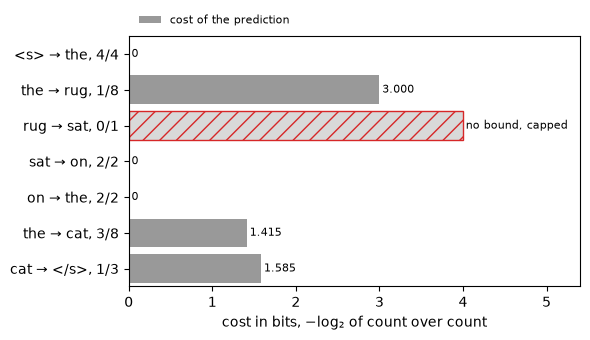

In [2]:
SENTENCE = "the rug sat on the cat"
rows = sentence(SENTENCE, "SENTENCE")
cost = [math.log2(C[u] / pairs[u, w]) if pairs[u, w] else None for u, w in rows]
show_bars([f"{u} → {w}, {pairs[u, w]}/{C[u]}" for u, w in rows],
          "cost in bits, −log₂ of count over count", {"cost of the prediction": cost})

### Solution

In [3]:
rows = sentence(SENTENCE, "SENTENCE")
zero = [f"{u} {w}" for u, w in rows if not pairs[u, w]]
refs = {s: sentence(s, "") for s in ("the cat sat on the mat", "the cat chased the dog")}
display(Markdown(
    (f'"{zero[0]}" never occurs in the four sentences: its factor and the product of all {len(rows)} are 0, and the perplexity has '
     'no bound, as on the frame "One Unseen Pair Gives ‘the rug sat on the cat’ Probability Zero". ' if zero else
     f"Every pair occurs: perplexity {perplexity(rows, addk):.2f}. ") + " and ".join(f'"{s}" multiplies {len(x)} factors to '
    f"{math.prod(addk(u, w) for u, w in x):.4f}, perplexity {perplexity(x, addk):.2f}" for s, x in refs.items())
    + ': one product over two N gives two perplexities (frame "One Sixty-Fourth Over Seven Predictions Is a Perplexity of ..."). '
    f'P(cat | the) = {addk("the", "cat"):.3f} (frame "Four Sentences Give the Context ‘the’ Eight Counts Over Four Next Words").'))

"rug sat" never occurs in the four sentences: its factor and the product of all 7 are 0, and the perplexity has no bound, as on the frame "One Unseen Pair Gives ‘the rug sat on the cat’ Probability Zero". "the cat sat on the mat" multiplies 7 factors to 0.0156, perplexity 1.81 and "the cat chased the dog" multiplies 6 factors to 0.0156, perplexity 2.00: one product over two N gives two perplexities (frame "One Sixty-Fourth Over Seven Predictions Is a Perplexity of ..."). P(cat | the) = 0.375 (frame "Four Sentences Give the Context ‘the’ Eight Counts Over Four Next Words").

## 2. How much probability unseen pairs get

Add-k smoothing adds k to the count of every pair, seen or unseen, so the
count of each first word grows by k once for each of the nine words a model
predicts. Run the cell with `K = 1`, then with `K = 0.01` and `K = 0`: how
much of the row of "the" goes to the words never seen after it, and how much
is left for "cat"?

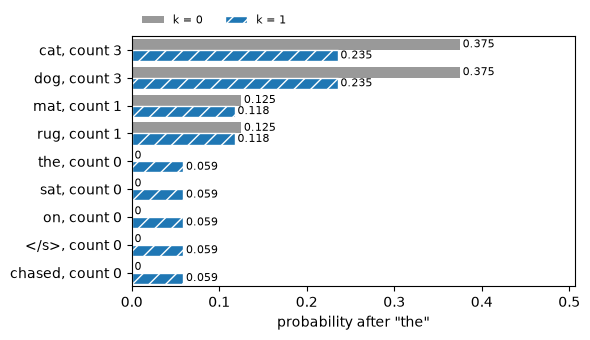

In [4]:
K = 1
row = sorted(NEXT, key=lambda w: -pairs["the", w])
probs = {f"k = {k:g}": [addk("the", w, k) for w in row] for k in (0, number(K, "K", 100))}
show_bars([f"{w}, count {pairs['the', w]}" for w in row], 'probability after "the"', probs)

### Solution

In [5]:
k = number(K, "K", 100)
display(Markdown(
    f'At k = {k:g} the {sum(not pairs["the", w] for w in NEXT)} words never seen after "the" get '
    f'{sum(addk("the", w, k) for w in NEXT if not pairs["the", w]):.2g} together, P(cat | the) {addk("the", "cat", k):.3f}, '
    f'"rug sat" {fmt(addk("rug", "sat", k))} (frame "Add-k Adds k to Every Cell and k Times |V| to Every Row", k = 1 and k = 0.01).'))

At k = 1 the 5 words never seen after "the" get 0.29 together, P(cat | the) 0.235, "rug sat" 0.100 (frame "Add-k Adds k to Every Cell and k Times |V| to Every Row", k = 1 and k = 0.01).

## 3. Which unseen words get it

Add-one gives every word never seen after a word the same share. Kneser-Ney
subtracts 0.75 from every seen count and shares the freed probability among
the next words by their continuation counts, the number of distinct words each
one follows. Run the cell, then type a held-out sentence of your own into
`TEST_SENTENCE`: which rule gives the unseen pair "rug sat" more, and which
gives the sentence the lower perplexity?

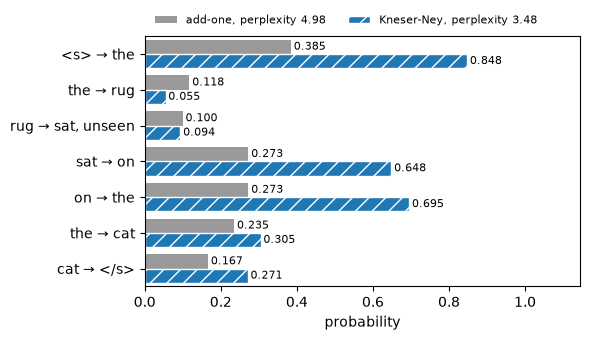

In [6]:
TEST_SENTENCE = "the rug sat on the cat"
rows = sentence(TEST_SENTENCE, "TEST_SENTENCE")
probs = {f"{n}, perplexity {perplexity(rows, p):.2f}": [p(u, w) for u, w in rows]
         for n, p in RULES.items()}
show_bars([f"{u} → {w}{'' if pairs[u, w] else ', unseen'}" for u, w in rows], "probability", probs)

### Solution

In [7]:
rows = sentence(TEST_SENTENCE, "TEST_SENTENCE")
u, w = next(((u, w) for u, w in rows if not pairs[u, w]), ("", ""))
rest = ", ".join(f'"{x}" {kn(u, x):.3f}' for x in sorted(NEXT, key=lambda x: -cont[x]) if u and not pairs[u, x])
display(Markdown(
    (f'Add-one gives every word unseen after "{u}", "{w}" among them, 1/{C[u] + V} = {addk(u, w, 1):.3f}; Kneser-Ney gives each '
     f"λ({u}) = {D * fol[u] / C[u]:.3g} times its continuation count over the {len(pairs)} pair types: {rest}. " if u else
     "Every pair occurs in the four sentences. ") + f"Perplexity: {perplexity(rows, RULES['add-one']):.2f} under add-one, "
    f'{perplexity(rows, kn):.2f} under Kneser-Ney; for "the rug sat on the cat" the frame "Add-One Scores ... and Kneser-Ney ... on '
    '‘the rug sat on the cat’" prints both.'))

Add-one gives every word unseen after "rug", "sat" among them, 1/10 = 0.100; Kneser-Ney gives each λ(rug) = 0.75 times its continuation count over the 16 pair types: "the" 0.141, "sat" 0.094, "chased" 0.094, "cat" 0.047, "on" 0.047, "mat" 0.047, "dog" 0.047, "rug" 0.047. Perplexity: 4.98 under add-one, 3.48 under Kneser-Ney; for "the rug sat on the cat" the frame "Add-One Scores ... and Kneser-Ney ... on ‘the rug sat on the cat’" prints both.

## Appendix. Perplexity and the limit of counting

Perplexity is two to the mean cost in bits of the N predictions a model makes
on a text it was not trained on:

PP = 2^(−(1/N) · Σ log₂ P(wᵢ | hᵢ)),

with `</s>` among the predictions and `<s>` given. One prediction of
probability 0 makes the sum unbounded, so under counting alone a text with
one unseen pair has a perplexity without bound. Two perplexities compare only
on the same test text, vocabulary, rule for unknown words and count of
predictions N.

An order-n model conditions each word on its history h, the n − 1 words
before it. Interpolated Kneser-Ney mixes every order with the one below it:

P(w | h) = max(C(h w) − D, 0) / C(h) + λ(h) · P(w | h′),  λ(h) = D · F(h) / C(h),

where h′ is h without its first word and F(h) the number of distinct words
seen after h. The highest order counts occurrences; each lower order counts,
for every n-gram, the distinct words seen before it. The unigram is mixed
with the uniform 1/V by the same rule, so `<unk>`, a test word the training
chapters lack, keeps a share, and a history the training chapters lack leaves
the prediction to the order below. The four sentences fix the discount D at
0.75; on the novel each order n takes the discount its own counts estimate,

D = n₁ / (n₁ + 2 n₂),

with n₁ and n₂ the numbers of n-grams of that order seen once and twice
(Ney, Essen and Kneser).

The models train on the first nine tenths of the novel's chapters at orders 1
to 5 and are tested on its last tenth, every order at the same test
positions; the novel's text has no `<s>` or `</s>`. Held-out perplexity, and
the share of the held-out n-grams the training chapters never contain:

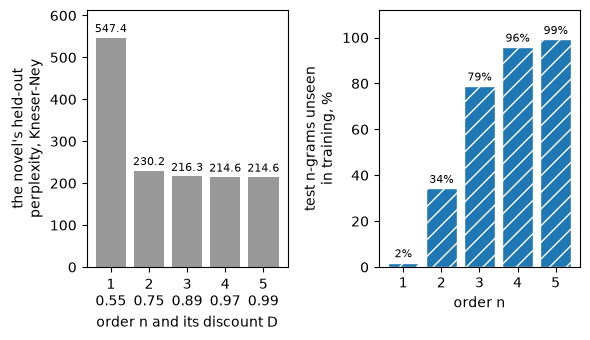

In [8]:
fig, (a, b) = plt.subplots(1, 2)
a.bar_label(a.bar(ORDERS, pp, **STYLES[0]), fmt="%.1f", fontsize=8, padding=2)
a.set(xticks=ORDERS, xticklabels=[f"{m}\n{DN[m]:.2f}" for m in ORDERS], ylim=(0, 1.12 * max(pp)),
      xlabel="order n and its discount D", ylabel="the novel's held-out\nperplexity, Kneser-Ney")
b.bar_label(b.bar(ORDERS, unseen, **STYLES[1]), fmt="%.0f%%", fontsize=8, padding=2)
b.set(xticks=ORDERS, xlabel="order n", ylim=(0, 112), ylabel="test n-grams unseen\nin training, %")
plt.show()

**Exercise.** None of "on", "mat" and "the" follows "cat" in the four
sentences. Set `WORD` to each in turn: why do add-one and Kneser-Ney give
"cat on", which English writes, exactly what they give "cat mat", and why does
Kneser-Ney put "the" above both?

In [9]:
WORD = "on"

w = need(WORD in NEXT, "WORD", WORD, f"it must be one of {', '.join(NEXT)}")
print(f'"cat {w}": add-one {fmt(addk("cat", w, 1))}, Kneser-Ney {fmt(kn("cat", w))}')

"cat on": add-one 0.083, Kneser-Ney 0.047


### Solution

In [10]:
steps = ", ".join(f"{b - a:+.2f}" for a, b in zip(pp, pp[1:]))
display(Markdown(
    f"Under each order's own discount the novel's held-out perplexity changes by {steps} from one order to the next, over "
    f'{len(AT):,} predictions.\n\nAfter "cat", add-one gives every unseen word 1/{C["cat"] + V} = {addk("cat", "on", 1):.3f}, and '
    f'Kneser-Ney gives "on" and "mat", each after {cont["on"]} word, {kn("cat", "on"):.3f} and "the", after {cont["the"]}, '
    f'{kn("cat", "the"):.3f}: both rules read only counts of words and of the words before them (frame "Add-One and Kneser-Ney '
    f'Give ‘cat on’ the Same Probability as ‘cat mat’").\n\nAfter "the cat sat on the", P(mat | the) = {pairs["the", "mat"]}/'
    f'{C["the"]} = {addk("the", "mat"):.3f}; the row of "the" sums to {sum(addk("the", x, 1) for x in NEXT):g} under add-one and '
    f'{sum(kn("the", x) for x in NEXT):g} under Kneser-Ney over the {V} words in the counts, so "bed" and "floor" get 0. GPT-2 gives '
    f'floor {GPT2["floor"]}, bed {GPT2["bed"]} and mat {GPT2["mat"]:.4f}, floor {GPT2["floor"] / GPT2["mat"]:.0f} times above mat '
    '(frame "Three Words After ‘the cat sat on the’, Counted and Predicted"): counting ranks mat first, GPT-2 last.'))

Under each order's own discount the novel's held-out perplexity changes by -317.17, -13.88, -1.71, -0.08 from one order to the next, over 12,140 predictions.

After "cat", add-one gives every unseen word 1/12 = 0.083, and Kneser-Ney gives "on" and "mat", each after 1 word, 0.047 and "the", after 3, 0.141: both rules read only counts of words and of the words before them (frame "Add-One and Kneser-Ney Give ‘cat on’ the Same Probability as ‘cat mat’").

After "the cat sat on the", P(mat | the) = 1/8 = 0.125; the row of "the" sums to 1 under add-one and 1 under Kneser-Ney over the 9 words in the counts, so "bed" and "floor" get 0. GPT-2 gives floor 0.0764, bed 0.0653 and mat 0.0040, floor 19 times above mat (frame "Three Words After ‘the cat sat on the’, Counted and Predicted"): counting ranks mat first, GPT-2 last.